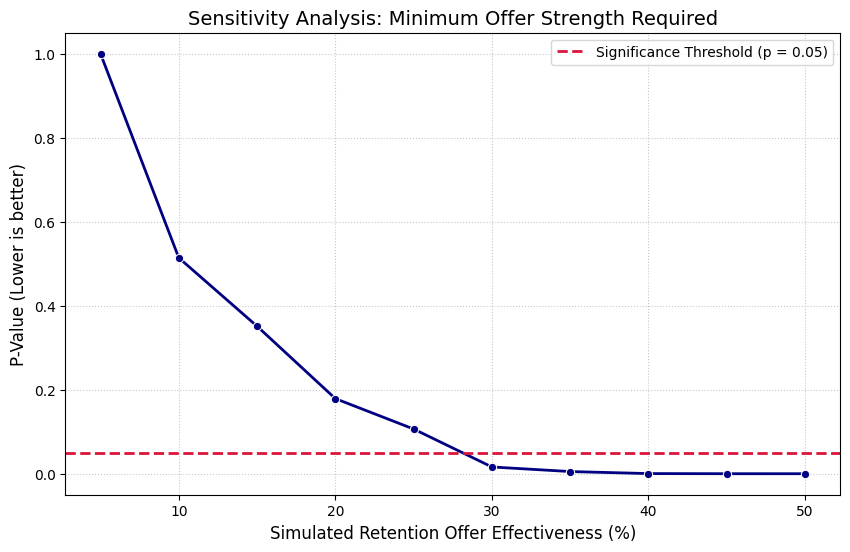

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data from Notebook 02
results_df = pd.read_csv('model_predictions.csv')

# 2. Isolate the high-risk customers
high_risk = results_df[results_df['Churn_Probability'] > 0.50].copy()

# 3. Set up our simulation parameters (testing 5% to 55% effectiveness)
effect_sizes = np.arange(0.05, 0.55, 0.05) 
p_values = []

# 4. Run the loop for every assumption
for effect in effect_sizes:
    np.random.seed(42) 
    high_risk['Group'] = np.where(np.random.rand(len(high_risk)) > 0.5, 'Treatment', 'Control')

    def apply_dynamic_effect(row):
        if row['Group'] == 'Treatment' and row['Actual_Churn'] == 1:
            return 0 if np.random.rand() < effect else 1
        return row['Actual_Churn']
    
    high_risk['Post_Campaign_Churn'] = high_risk.apply(apply_dynamic_effect, axis=1)
    
    contingency_table = pd.crosstab(high_risk['Group'], high_risk['Post_Campaign_Churn'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    p_values.append(p_value)

# 5. Plot the Sensitivity Analysis
plt.figure(figsize=(10, 6))
sns.lineplot(x=[e * 100 for e in effect_sizes], y=p_values, marker='o', linewidth=2, color='navy')

# Add the 95% confidence threshold line (p = 0.05)
plt.axhline(y=0.05, color='crimson', linestyle='--', linewidth=2, label='Significance Threshold (p = 0.05)')

# Formatting the chart
plt.title('Sensitivity Analysis: Minimum Offer Strength Required', fontsize=14)
plt.xlabel('Simulated Retention Offer Effectiveness (%)', fontsize=12)
plt.ylabel('P-Value (Lower is better)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [8]:
# Reset the simulation back to a strict 25% effect
np.random.seed(42)
high_risk['Group'] = np.where(np.random.rand(len(high_risk)) > 0.5, 'Treatment', 'Control')

def apply_original_effect(row):
    if row['Group'] == 'Treatment' and row['Actual_Churn'] == 1:
        return 0 if np.random.rand() < 0.25 else 1
    return row['Actual_Churn']

high_risk['Post_Campaign_Churn'] = high_risk.apply(apply_original_effect, axis=1)

In [9]:
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower

# 1. Prepare the data for the Z-Test
control_churned = high_risk[high_risk['Group'] == 'Control']['Post_Campaign_Churn'].sum()
treat_churned = high_risk[high_risk['Group'] == 'Treatment']['Post_Campaign_Churn'].sum()
n_control = (high_risk['Group'] == 'Control').sum()
n_treat = (high_risk['Group'] == 'Treatment').sum()

# 2. Run the Two-Proportion Z-Test
counts = np.array([treat_churned, control_churned])
nobs = np.array([n_treat, n_control])
stat, pval = proportions_ztest(counts, nobs)

# 3. Calculate Confidence Interval for the difference in proportions
p_treat = treat_churned / n_treat
p_control = control_churned / n_control
se = np.sqrt(p_treat * (1 - p_treat) / n_treat + p_control * (1 - p_control) / n_control)
ci_lower = (p_control - p_treat) - 1.96 * se
ci_upper = (p_control - p_treat) + 1.96 * se

print("=== STATISTICAL ANALYSIS ===")
print(f"Z-Statistic: {stat:.3f}")
print(f"P-Value: {pval:.4f}")
print(f"Effect Size (Absolute Reduction): {(p_control - p_treat) * 100:.2f}%")
print(f"95% Confidence Interval for Effect Size: [{ci_lower * 100:.2f}%, {ci_upper * 100:.2f}%]\n")

# 4. Power Analysis: Minimum Detectable Effect (MDE)
# Given our sample size, 5% alpha, and standard 80% power, what is the smallest effect we could detect?
analysis = NormalIndPower()
mde = analysis.solve_power(power=0.80, alpha=0.05, nobs1=n_treat, ratio=n_control/n_treat)

print("=== POWER ANALYSIS ===")
print(f"Minimum Detectable Effect (Cohen's h): {mde:.4f}")
print("Business Translation: Given our small sample of high-risk customers, the campaign must have a massive impact to register as statistically significant.")

=== STATISTICAL ANALYSIS ===
Z-Statistic: -1.753
P-Value: 0.0796
Effect Size (Absolute Reduction): 10.53%
95% Confidence Interval for Effect Size: [-1.18%, 22.23%]

=== POWER ANALYSIS ===
Minimum Detectable Effect (Cohen's h): 0.3617
Business Translation: Given our small sample of high-risk customers, the campaign must have a massive impact to register as statistically significant.
